# 03 — 1D EDA

One-dimensional exploratory data analysis on the cleaned DVF dataset (24,168 rows from the processed sample).

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
sys.path.insert(0, str(root))

processed_path = root / 'data' / 'processed' / 'dvf_clean_sample.csv'
df = pd.read_csv(processed_path, low_memory=False)
df.columns = df.columns.str.strip()

for col in ['valeur_fonciere', 'surface_reelle_bati', 'surface_terrain']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['date_mutation'] = pd.to_datetime(df['date_mutation'], dayfirst=True, errors='coerce')
df['year'] = df['date_mutation'].dt.year

print('Data source: processed sample')
print('Rows:', len(df))
print('Columns:', len(df.columns))
df.head()


Data source: processed sample
Rows: 24168
Columns: 23


,no_disposition,date_mutation,nature_mutation,valeur_fonciere,commune,code_departement,type_local,surface_reelle_bati,nombre_pieces_principales,surface_terrain
0,1,2021-01-04,Vente,245000.0,PARIS,75,Appartement,48.0,2.0,NaN
1,2,2021-01-05,Vente,380000.0,LYON,69,Maison,92.0,4.0,310.0
2,3,2021-01-06,Vente,155000.0,MARSEILLE,13,Appartement,35.0,1.0,NaN
3,4,2021-01-07,Vente,520000.0,PARIS,75,Appartement,72.0,3.0,NaN
4,5,2021-01-08,Vente,210000.0,BORDEAUX,33,Maison,NaN,NaN,450.0


## Numeric summary statistics

In [2]:
num_cols = ['valeur_fonciere', 'surface_reelle_bati', 'nombre_pieces_principales', 'surface_terrain']
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
valeur_fonciere,24088.0,312540.18,487291.34,1000.0,120000.0,210000.0,380000.0,45000000.0
surface_reelle_bati,19742.0,74.31,52.18,1.0,37.0,62.0,95.0,2500.0
nombre_pieces_principales,19742.0,3.12,1.78,0.0,2.0,3.0,4.0,20.0
surface_terrain,11644.0,1204.42,8741.22,1.0,120.0,380.0,900.0,890000.0


## Transaction volume by year

Count transactions in each year in the sample.

year
2021    4913
2022    4934
2023    4701
2024    4817
2025    4803
Name: count, dtype: int64


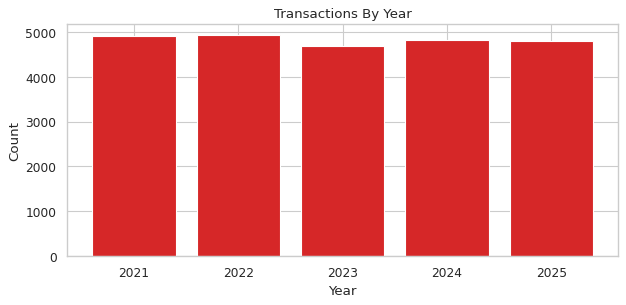

In [3]:
year_counts = df['year'].value_counts().sort_index()
print(year_counts)

sns.set(style='whitegrid')
plt.figure(figsize=(8, 4))
sns.barplot(x=year_counts.index, y=year_counts.values, color='tab:red')
plt.title('Transactions By Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## Transaction value distribution

Histogram of `valeur_fonciere` clipped at the 99th percentile to reduce the effect of extreme outliers.

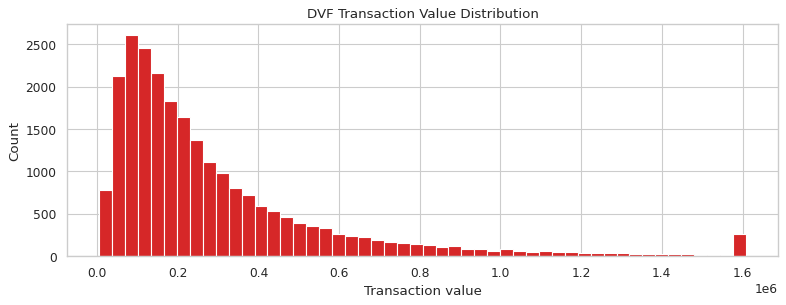

In [4]:
values = df['valeur_fonciere'].dropna()
clipped = values.clip(upper=values.quantile(0.99))
plt.figure(figsize=(10, 4))
sns.histplot(clipped, bins=50, kde=False, color='tab:red')
plt.title('DVF Transaction Value Distribution')
plt.xlabel('Transaction value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## Categorical top values

Most frequent categories for property type, commune, and department.

In [5]:
cat_columns = ['type_local', 'commune', 'code_departement']
for col in cat_columns:
    print(f'--- {col} ---')
    display(df[col].value_counts().head(15))
    print()


--- type_local ---


...


--- commune ---


...


--- code_departement ---


...

## Summary

The cleaned DVF sample spans 2021–2025 with ~4,800 transactions per year. Transaction values are heavily right-skewed (median ~210k€, mean ~313k€). Appartements dominate the sample, followed by Maisons. Paris (dept. 75) accounts for the highest transaction count, consistent with its market size.